# Study 781 — Quad-Witching-Hangover 🗓️

*For the curious.* Four times a year — the third Friday of March, June, September and December — four classes of derivatives expire at once: "quadruple witching." Trader-lore says the market is left **hungover** the following week, drifting lower after the expiration churn. We put all 84 quad-witching Fridays (2005→2025) on the stand and asked the tape one plain question: **does the week after quad-witching underperform?**

## The claim, and why it's a clean test

Quad-witching is a fixture of the exchange calendar — literally *third Friday of the quarter's last month* — so it is **known years ahead**. A "sit out / short the week after" rule is calendar-known and zero-look-ahead. We test `SPY`'s own forward return (SPY *is* the index, so there's no separate benchmark) and judge "underperform" against SPY's ordinary drift via a random-window placebo.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from quad_witching_hangover import data as dt, strategy as st

if not dt.have_real():
    print("cache miss -> fetching SPY once (needs network)")
    dt.fetch()
prices = dt.load_real()
ev = st.build_event_table(prices, cost_bps=5.0)
inc = ev[ev["included"]]
print(f"panel loaded; {len(inc)} of {len(dt.EVENTS)} quad-witching Fridays resolved")


panel loaded; 84 of 84 quad-witching Fridays resolved


## The quad-witching calendar we test (hardcoded, third Fridays)

In [2]:
pd.DataFrame(dt.EVENTS, columns=['date','year','quarter']).head(12)

,date,year,quarter
0,2005-03-18,2005,Mar
1,2005-06-17,2005,Jun
2,2005-09-16,2005,Sep
3,2005-12-16,2005,Dec
4,2006-03-17,2006,Mar
5,2006-06-16,2006,Jun
6,2006-09-15,2006,Sep
7,2006-12-15,2006,Dec
8,2007-03-16,2007,Mar
9,2007-06-15,2007,Jun


## The picture: mean cumulative SPY return around quad-witching

Offset 0 is the quad-witching close. Left of zero is the *run-in*; right of zero is the *hangover* window the folklore says should sag.

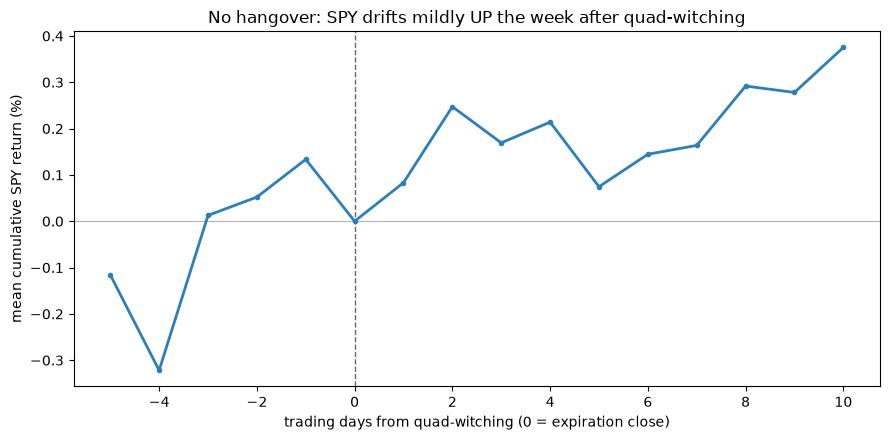

In [3]:
car = st.car_path(ev, prices)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvline(0, color='0.4', lw=1, ls='--')
ax.axhline(0, color='0.7', lw=0.8)
ax.plot(car.index, car.values * 100, color='#2c7fb8', lw=2, marker='o', ms=3)
ax.set_xlabel('trading days from quad-witching (0 = expiration close)')
ax.set_ylabel('mean cumulative SPY return (%)')
ax.set_title('No hangover: SPY drifts mildly UP the week after quad-witching')
plt.tight_layout(); plt.show()

## The numbers

| window | mean | *t* | up-rate |
|---|--:|--:|--:|
| 1-week hangover | **+0.07%** | **+0.28** | 35/84 |
| 2-week give-back | +0.38% | +0.94 | 53/84 |
| 1-week run-in | +0.19% | +0.66 | 51/84 |

The folklore is **wrong on the sign**: the week *after* quad-witching returns +0.07% on average (*t* = +0.28) — mildly *positive*, not a hangover. Two weeks out it's more positive still (+0.38%). There is simply no underperformance to trade.

In [4]:
rows = [('1wk hangover','post_s'),('2wk give-back','post_l'),('1wk run-in','pre')]
for label, col in rows:
    s = st.one_sample_t(inc[col].values); hr = st.hit_rate(inc[col].values)
    print(f'{label:<14s} n={s["n"]:2d}  mean={s["mean"]*100:+.3f}%  t={s["t"]:+.3f}  up {hr["k"]}/{hr["n"]}')

1wk hangover   n=84  mean=+0.075%  t=+0.276  up 35/84
2wk give-back  n=84  mean=+0.375%  t=+0.937  up 53/84
1wk run-in     n=84  mean=+0.188%  t=+0.660  up 51/84


## So what?

The "quad-witching hangover" is a myth. SPY's week after quarterly quad-witching is *positive* (+0.08%), sits dead-centre of the random-window placebo, and its *t*-stat is a rounding error. Verdict: **Signal None, Tradability Mirage.** The quants' notebook has the placebo, the jackknife, the costed leg and the synthetic control that proves the detector *would* catch a real hangover if one existed.